## Librerías

In [11]:
!gdown --folder https://drive.google.com/drive/folders/1U-qVetDOlaku-vS8HEndCPbi_S6q_gAU?usp=drive_link

Processing file 1keAKkZY2UBXsKc2fgMBSsBsBkcK3kR4m Clasificacion Biomas Minecraft.folder.zip


Retrieving folder contents
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1keAKkZY2UBXsKc2fgMBSsBsBkcK3kR4m
From (redirected): https://drive.google.com/uc?id=1keAKkZY2UBXsKc2fgMBSsBsBkcK3kR4m&confirm=t&uuid=e405c291-d2f6-4c32-b292-b7f65d0b5efe
To: c:\Users\Lenovo\Desktop\Clasificacion-Biomas-Minecraft\Dataset-Minecraft\Clasificacion Biomas Minecraft.folder.zip

  0%|          | 0.00/386M [00:00<?, ?B/s]
  0%|          | 1.05M/386M [00:00<00:47, 8.09MB/s]
  1%|          | 3.15M/386M [00:00<00:30, 12.7MB/s]
  1%|▏         | 5.77M/386M [00:00<00:22, 17.2MB/s]
  2%|▏         | 7.86M/386M [00:00<00:22, 17.1MB/s]
  3%|▎         | 10.5M/386M [00:00<00:20, 18.4MB/s]
  3%|▎         | 12.6M/386M [00:00<00:20, 18.6MB/s]
  4%|▍         | 14.7M/386M [00:00<00:20, 17.9MB/s]
  4%|▍         | 16.8M/386M [00:01<00:22, 16.7MB/s]
  5%|▍         | 18.9M/386M [00:01<00:22, 16.2MB/s]
  5%

In [ ]:
import zipfile
import os

archivo_zip = 'Dataset-Minecraft/Clasificacion Biomas Minecraft.folder.zip' 
carpeta_destino = 'c:/Users/Lenovo/Desktop/Clasificacion-Biomas-Minecraft'

with zipfile.ZipFile(archivo_zip, 'r') as zip_ref:
    zip_ref.extractall(carpeta_destino)
    print(f"Archivos extraídos correctamente en: {carpeta_destino}")

Archivos extraídos correctamente en: c:/Users/Lenovo/Desktop/Clasificacion-Biomas-Minecraft


In [14]:
import torch
import numpy as np
import random
import numpy as np
import time
import tensorflow as tf
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torchvision import datasets
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torch.nn as nn

In [ ]:
import sys
import torch

print(f"El Notebook está usando: {sys.executable}")

!{sys.executable} -m pip uninstall -y torch torchvision torchaudio

!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --force-reinstall

El Notebook está usando: c:\Users\Lenovo\Desktop\Clasificacion-Biomas-Minecraft\venv\Scripts\python.exe
Found existing installation: torch 2.7.1+cu118
Uninstalling torch-2.7.1+cu118:
  Successfully uninstalled torch-2.7.1+cu118
Found existing installation: torchvision 0.22.1+cu118
Uninstalling torchvision-0.22.1+cu118:
  Successfully uninstalled torchvision-0.22.1+cu118
Found existing installation: torchaudio 2.7.1+cu118
Uninstalling torchaudio-2.7.1+cu118:
  Successfully uninstalled torchaudio-2.7.1+cu118
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download-r2.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (27 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadat

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Configuración básica

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Fijar semilla para reproducibilidad
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

Usando dispositivo: cuda


In [16]:
import cv2 as cv
import numpy as np
import os

carpeta_origen = 'train'
carpeta_destino = 'trainProcesado_cutout'

azul_bajo = np.array([90, 50, 50])
azul_alto = np.array([130, 255, 255])

# RECORRER CARPETAS
for carpeta_actual, subcarpetas, archivos in os.walk(carpeta_origen):
    # Crear la misma carpeta en el destino
    ruta_destino_actual = carpeta_actual.replace(carpeta_origen, carpeta_destino)
    os.makedirs(ruta_destino_actual, exist_ok=True)

    for nombre_archivo in archivos:
        if nombre_archivo.lower().endswith('.jpg'):
            
            # 1. LEER: Cargar la imagen original
            ruta_completa = os.path.join(carpeta_actual, nombre_archivo)
            imagen = cv.imread(ruta_completa)
            
            hsv = cv.cvtColor(imagen, cv.COLOR_BGR2HSV)
            
            mascara_azul = cv.inRange(hsv, azul_bajo, azul_alto)
            
            mascara_limpia = cv.bitwise_not(mascara_azul)
            
            resultado = cv.bitwise_and(imagen, imagen, mask=mascara_limpia)
            
            # 3. GUARDAR: Guardar el resultado en la nueva carpeta
            ruta_salida = os.path.join(ruta_destino_actual, nombre_archivo)
            cv.imwrite(ruta_salida, resultado)

print("¡Proceso terminado con éxito!")

¡Proceso terminado con éxito!


## Rutas conjunto de datos(train-test)

In [17]:
train_dir = "train"
test_dir = "test"
valid_dir = "valid"

## Análisis de conjunto de datos(train)

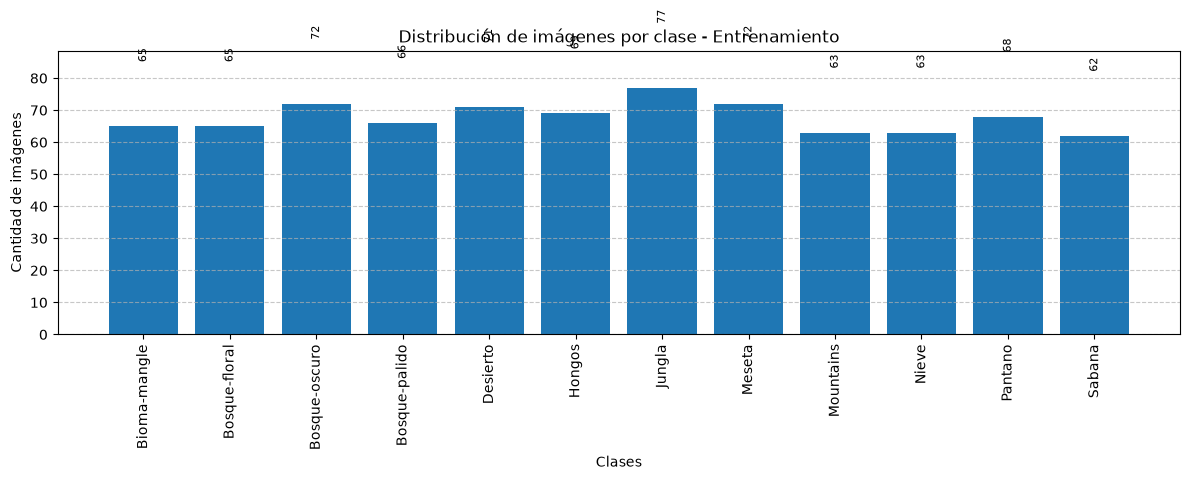

In [18]:

classes = sorted(os.listdir(train_dir))
num_images = []
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        num_images.append(count)

plt.figure(figsize=(12,5))
plt.bar(range(len(classes)), num_images)
plt.xticks(range(len(classes)), classes, rotation=90)
plt.xlabel("Clases")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase - Entrenamiento")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, count in enumerate(num_images):
    plt.text(i, count + 20, str(count), ha='center', va='bottom', fontsize=8, rotation=90)

plt.ylim(0, max(num_images) * 1.15)

plt.tight_layout()
plt.show()

## Normalizar datos de entrenamiento y prueba

In [30]:
train_dir = "trainProcesado_cutout" 
valid_dir = "valid"
test_dir = "test"

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

train_dataset = ImageFolder(root=train_dir, transform=data_transforms)
valid_dataset = ImageFolder(root=valid_dir, transform=data_transforms)
test_dataset = ImageFolder(root=test_dir, transform=data_transforms)

num_classes = len(train_dataset.classes)

batch_size = 32

shuffle=True
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f" Número de imágenes de entrenamiento (Sin agua): {len(train_dataset)}")
print(f" Número de imágenes de validación: {len(valid_dataset)}")
print(f" Número de imágenes de prueba: {len(test_dataset)}")
print("-" * 50)
print(f" Número de lotes (batches) en train_loader: {len(train_loader)}")
print(f" Número de lotes (batches) en valid_loader: {len(valid_loader)}")
print(f" Número de lotes (batches) en test_loader: {len(test_loader)}")
print("-" * 50)
print(f" Clases detectadas automáticamente: {train_dataset.classes}")

 Número de imágenes de entrenamiento (Sin agua): 813
 Número de imágenes de validación: 238
 Número de imágenes de prueba: 115
--------------------------------------------------
 Número de lotes (batches) en train_loader: 26
 Número de lotes (batches) en valid_loader: 8
 Número de lotes (batches) en test_loader: 4
--------------------------------------------------
 Clases detectadas automáticamente: ['Bioma-mangle', 'Bosque-floral', 'Bosque-oscuro', 'Bosque-palido', 'Desierto', 'Hongos', 'Jungla', 'Meseta', 'Mountains', 'Nieve', 'Pantano', 'Sabana']


## Cargar modelo preentrenado ResNet50

In [31]:
model = models.resnet50(weights="IMAGENET1K_V1")

In [32]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [33]:
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4), #cambiar neuronas que se apagan                  
    nn.Linear(in_features, num_classes)
)

# Congelar todas las capas excepto layer4 y fc
for name, param in model.named_parameters():
    if "fc" in name or "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Verificar capas entrenables
params_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
params_totales     = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {params_entrenables:,} / {params_totales:,}")
print(f"Porcentaje entrenable : {100 * params_entrenables / params_totales:.1f}%")

model = model.to(device)
print("\nModelo listo en:", device)

Parámetros entrenables: 14,989,324 / 23,532,620
Porcentaje entrenable : 63.7%

Modelo listo en: cuda


In [34]:
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

## Entrenamiento

In [35]:
epochs = 30
model = model.to(device)

best_test_acc = 0.0
save_path = "resnet50_best.pt"
start = time.time()

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()                # Reiniciar gradientes
        outputs = model(imgs)                # Forward pass
        loss = criterion(outputs, labels)    # Calcular pérdida
        loss.backward()                      # Backpropagation
        optimizer.step()                     # Actualizar pesos

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = total_loss / total

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_acc = test_correct / test_total

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Test Acc: {test_acc*100:.2f}%")

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), save_path)
        print(f"Mejor modelo guardado en '{save_path}' (Test Acc: {best_test_acc*100:.2f}%)")

end = time.time()
print(f"Tiempo de entrenamiento: {(end-start)/60:.3f} minutos")
print(f"Mejor accuracy de prueba: {best_test_acc*100:.2f}%")

Epoch [1/30] | Train Loss: 1.6835 | Train Acc: 52.77% | Test Acc: 83.48%
Mejor modelo guardado en 'resnet50_best.pt' (Test Acc: 83.48%)
Epoch [2/30] | Train Loss: 0.5070 | Train Acc: 90.53% | Test Acc: 89.57%
Mejor modelo guardado en 'resnet50_best.pt' (Test Acc: 89.57%)
Epoch [3/30] | Train Loss: 0.1466 | Train Acc: 97.54% | Test Acc: 87.83%
Epoch [4/30] | Train Loss: 0.0684 | Train Acc: 99.51% | Test Acc: 90.43%
Mejor modelo guardado en 'resnet50_best.pt' (Test Acc: 90.43%)
Epoch [5/30] | Train Loss: 0.0309 | Train Acc: 100.00% | Test Acc: 91.30%
Mejor modelo guardado en 'resnet50_best.pt' (Test Acc: 91.30%)
Epoch [6/30] | Train Loss: 0.0184 | Train Acc: 100.00% | Test Acc: 91.30%
Epoch [7/30] | Train Loss: 0.0125 | Train Acc: 100.00% | Test Acc: 88.70%
Epoch [8/30] | Train Loss: 0.0162 | Train Acc: 99.75% | Test Acc: 91.30%
Epoch [9/30] | Train Loss: 0.0189 | Train Acc: 99.75% | Test Acc: 89.57%
Epoch [10/30] | Train Loss: 0.0124 | Train Acc: 100.00% | Test Acc: 87.83%
Epoch [11/30]


Imagen: test\Bosque-palido\Minecraft 26_2 - Un jugador 2026-06-16 22-41-58_mp4-0213_jpg.rf.jb9CY6v0dkEF1k0PEYAw.jpg
Clase real: Bosque-palido


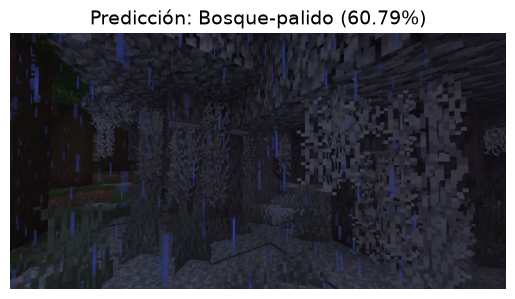


Probabilidades por clase:
  Bioma-mangle: 28.55%
  Bosque-floral: 0.56%
  Bosque-oscuro: 2.42%
  Bosque-palido: 60.79%
  Desierto: 0.36%
  Hongos: 1.10%
  Jungla: 0.42%
  Meseta: 0.31%
  Mountains: 0.52%
  Nieve: 0.17%
  Pantano: 4.61%
  Sabana: 0.20%

Imagen: test\Sabana\Minecraft 26_1_2 - Un jugador 2026-06-13 13-27-17_mp4-0006_jpg.rf.vpK3pe11Xy9GNSY8Ctf5.jpg
Clase real: Sabana


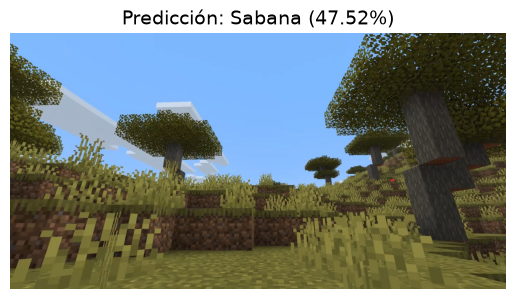


Probabilidades por clase:
  Bioma-mangle: 46.72%
  Bosque-floral: 0.07%
  Bosque-oscuro: 0.74%
  Bosque-palido: 0.26%
  Desierto: 0.10%
  Hongos: 0.32%
  Jungla: 0.08%
  Meseta: 1.34%
  Mountains: 2.76%
  Nieve: 0.06%
  Pantano: 0.03%
  Sabana: 47.52%

Imagen: test\Sabana\Minecraft 26_1_2 - Un jugador 2026-06-13 13-27-17_mp4-0061_jpg.rf.UIKuLiORl1VziMJUMlpt.jpg
Clase real: Sabana


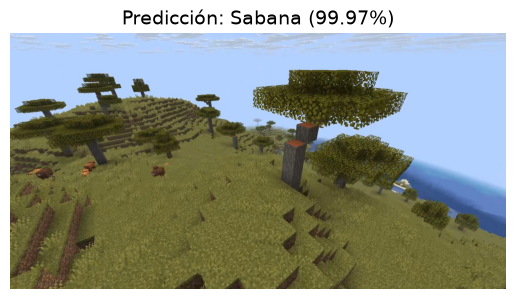


Probabilidades por clase:
  Bioma-mangle: 0.01%
  Bosque-floral: 0.00%
  Bosque-oscuro: 0.00%
  Bosque-palido: 0.00%
  Desierto: 0.00%
  Hongos: 0.00%
  Jungla: 0.00%
  Meseta: 0.00%
  Mountains: 0.00%
  Nieve: 0.00%
  Pantano: 0.00%
  Sabana: 99.97%

Imagen: test\Bioma-mangle\Minecraft 26_1_2 - Un jugador 2026-06-09 23-05-53_mp4-0077_jpg.rf.O6T58eaBjWf8Ox0uh0lE.jpg
Clase real: Bioma-mangle


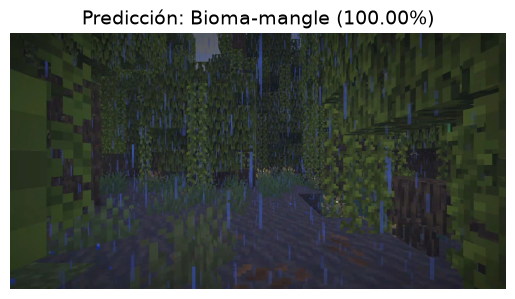


Probabilidades por clase:
  Bioma-mangle: 100.00%
  Bosque-floral: 0.00%
  Bosque-oscuro: 0.00%
  Bosque-palido: 0.00%
  Desierto: 0.00%
  Hongos: 0.00%
  Jungla: 0.00%
  Meseta: 0.00%
  Mountains: 0.00%
  Nieve: 0.00%
  Pantano: 0.00%
  Sabana: 0.00%

Imagen: test\Pantano\Minecraft 26_2 - Un jugador 2026-06-20 16-05-51_mp4-0052_jpg.rf.Kk3F3kyLQrK5AYva2PCO.jpg
Clase real: Pantano


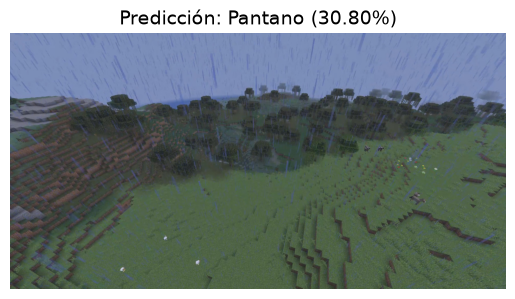


Probabilidades por clase:
  Bioma-mangle: 10.50%
  Bosque-floral: 0.73%
  Bosque-oscuro: 12.42%
  Bosque-palido: 0.74%
  Desierto: 5.27%
  Hongos: 1.89%
  Jungla: 15.89%
  Meseta: 1.18%
  Mountains: 15.82%
  Nieve: 0.46%
  Pantano: 30.80%
  Sabana: 4.31%

Imagen: test\Bosque-oscuro\Minecraft 26_2 - Un jugador 2026-06-19 23-11-59_mp4-0000_jpg.rf.ESdrshCb1qtDEqiUVLvH.jpg
Clase real: Bosque-oscuro


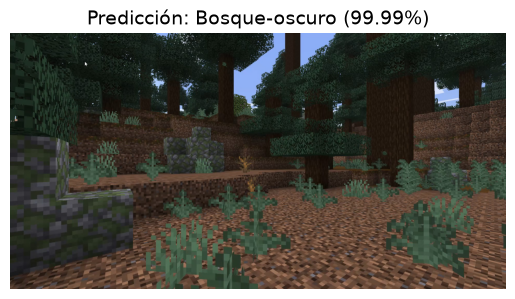


Probabilidades por clase:
  Bioma-mangle: 0.00%
  Bosque-floral: 0.00%
  Bosque-oscuro: 99.99%
  Bosque-palido: 0.01%
  Desierto: 0.00%
  Hongos: 0.00%
  Jungla: 0.00%
  Meseta: 0.00%
  Mountains: 0.00%
  Nieve: 0.00%
  Pantano: 0.00%
  Sabana: 0.00%

Imagen: test\Nieve\Minecraft 26_2 - Un jugador 2026-06-16 23-50-58_mp4-0012_jpg.rf.sWiWYQaXAHMjg4eifH1A.jpg
Clase real: Nieve


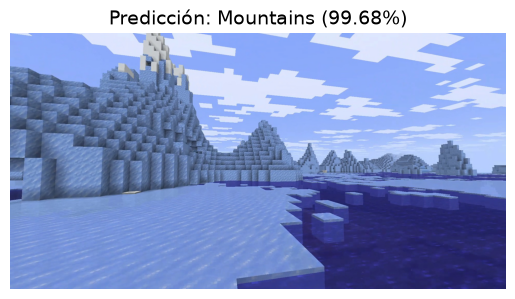


Probabilidades por clase:
  Bioma-mangle: 0.04%
  Bosque-floral: 0.01%
  Bosque-oscuro: 0.18%
  Bosque-palido: 0.00%
  Desierto: 0.02%
  Hongos: 0.01%
  Jungla: 0.00%
  Meseta: 0.01%
  Mountains: 99.68%
  Nieve: 0.04%
  Pantano: 0.00%
  Sabana: 0.00%

Imagen: test\Jungla\Minecraft 26_2 - Un jugador 2026-06-20 15-51-14_mp4-0090_jpg.rf.8exWYJuBK37bTuqEirIS.jpg
Clase real: Jungla


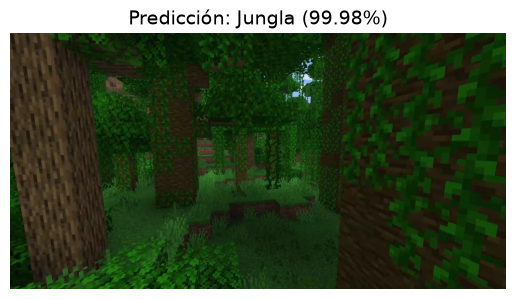


Probabilidades por clase:
  Bioma-mangle: 0.00%
  Bosque-floral: 0.00%
  Bosque-oscuro: 0.00%
  Bosque-palido: 0.00%
  Desierto: 0.00%
  Hongos: 0.00%
  Jungla: 99.98%
  Meseta: 0.00%
  Mountains: 0.00%
  Nieve: 0.00%
  Pantano: 0.01%
  Sabana: 0.00%

Imagen: test\Desierto\Minecraft 26_1_2 - Un jugador 2026-06-13 13-09-28_mp4-0077_jpg.rf.5ZFxtuP0ntCApcYHOfBR.jpg
Clase real: Desierto


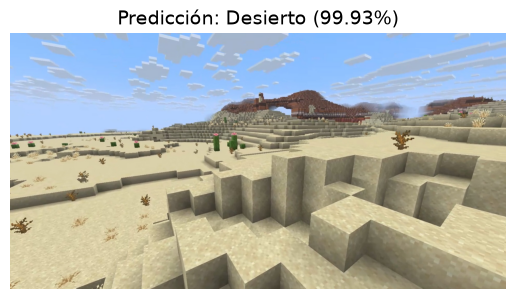


Probabilidades por clase:
  Bioma-mangle: 0.00%
  Bosque-floral: 0.00%
  Bosque-oscuro: 0.01%
  Bosque-palido: 0.00%
  Desierto: 99.93%
  Hongos: 0.00%
  Jungla: 0.00%
  Meseta: 0.03%
  Mountains: 0.00%
  Nieve: 0.00%
  Pantano: 0.00%
  Sabana: 0.01%

Imagen: test\Bosque-oscuro\Minecraft 26_2 - Un jugador 2026-06-16 23-50-58_mp4-0149_jpg.rf.bk7g3TqmD94UWYK2NmcZ.jpg
Clase real: Bosque-oscuro


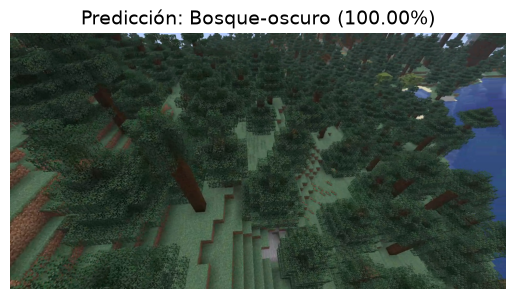


Probabilidades por clase:
  Bioma-mangle: 0.00%
  Bosque-floral: 0.00%
  Bosque-oscuro: 100.00%
  Bosque-palido: 0.00%
  Desierto: 0.00%
  Hongos: 0.00%
  Jungla: 0.00%
  Meseta: 0.00%
  Mountains: 0.00%
  Nieve: 0.00%
  Pantano: 0.00%
  Sabana: 0.00%


In [ ]:
import os
import random

def predecir_imagen(ruta_imagen):
    img = Image.open(ruta_imagen).convert("RGB")
    tensor = data_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        top_prob, top_idx = probs.max(0)

    clase_predicha = train_dataset.classes[top_idx.item()]
    confianza = top_prob.item() * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción: {clase_predicha} ({confianza:.2f}%)", fontsize=14)
    plt.show()

    print("\nProbabilidades por clase:")
    for i, clase in enumerate(train_dataset.classes):
        print(f"  {clase}: {probs[i].item()*100:.2f}%")

def predecir_desde_carpeta(carpeta, n=5):
    imagenes = []
    for clase in os.listdir(carpeta):
        clase_path = os.path.join(carpeta, clase)
        if os.path.isdir(clase_path):
            for archivo in os.listdir(clase_path):
                if archivo.lower().endswith((".jpg")):
                    imagenes.append(os.path.join(clase_path, archivo))

    # Tomar n imágenes aleatorias
    muestra = random.sample(imagenes, min(n, len(imagenes)))

    for ruta in muestra:
        clase_real = os.path.basename(os.path.dirname(ruta))
        print(f"\nImagen: {ruta}")
        print(f"Clase real: {clase_real}")
        predecir_imagen(ruta)
        
predecir_desde_carpeta("test", n=10)

## Matriz de confusión

In [ ]:
all_preds, all_labels = [], []

# No calcular gradientes (modo evaluación)
with torch.no_grad():
    for imgs, labels in test_loader: # Iterar sobre batches de validación
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Reporte de clasificación

In [ ]:
# Reporte por clase
print(classification_report(all_labels, all_preds, target_names=classes, digits=3))

## Clasificar una imagen

In [ ]:
img_path = "test"

pil_img = Image.open(img_path)

inference_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

img_tensor = inference_transforms(pil_img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_class_idx = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_class_idx].item()

predicted_class_name = classes[pred_class_idx]
print(f"Predicción: {predicted_class_name} con confianza {confidence*100:.2f}%")

plt.imshow(pil_img)
plt.title(f"Predicción: {predicted_class_name} ({confidence*100:.1f}%)")
plt.axis("off")
plt.show()